In [1]:
import pandas as pd

df = pd.read_csv("loan_data.csv")

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [2]:
df.shape

(614, 13)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [4]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [5]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

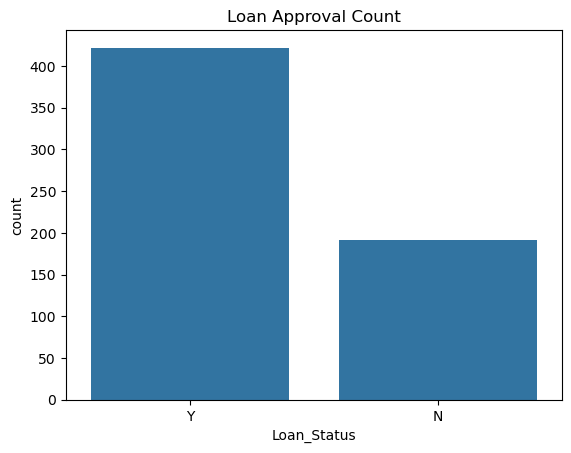

In [6]:
import matplotlib.pyplot as plt

import seaborn as sns

sns.countplot(x='Loan_Status',data=df)

plt.title("Loan Approval Count")

plt.show()

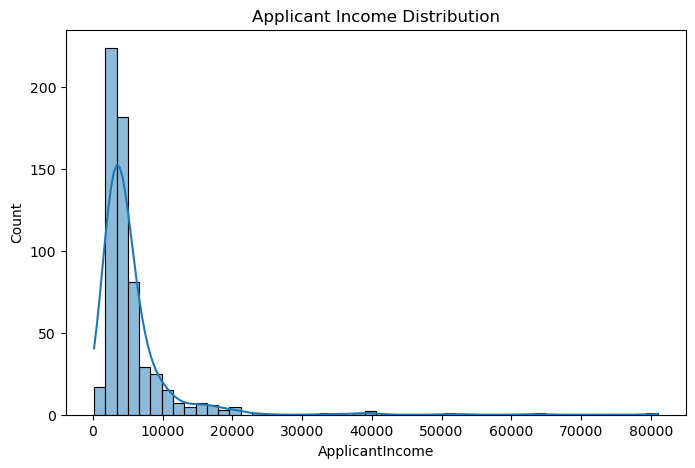

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(df['ApplicantIncome'],kde=True)

plt.title("Applicant Income Distribution")

plt.show()

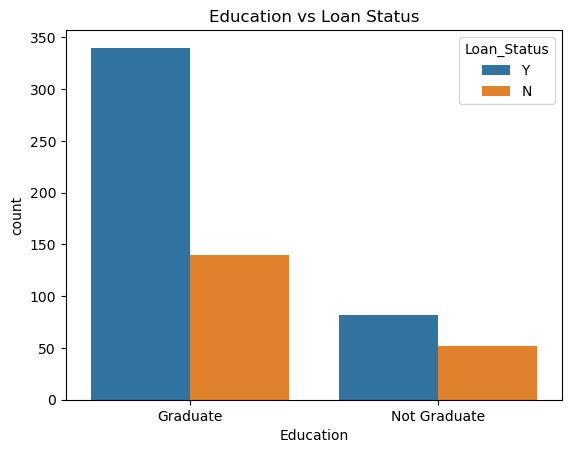

In [8]:
sns.countplot(

x='Education',

hue='Loan_Status',

data=df

)

plt.title("Education vs Loan Status")

plt.show()

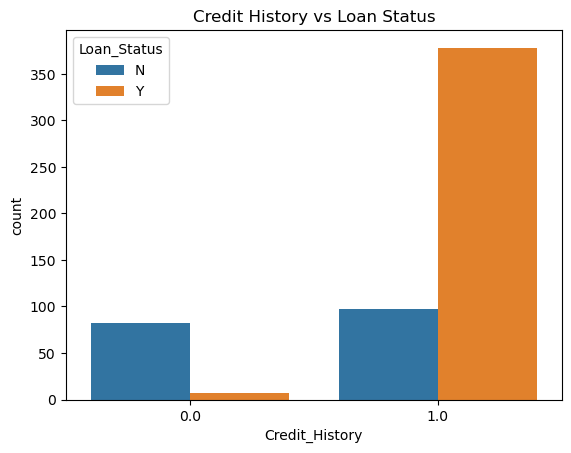

In [9]:
sns.countplot(

x='Credit_History',

hue='Loan_Status',

data=df

)

plt.title("Credit History vs Loan Status")

plt.show()

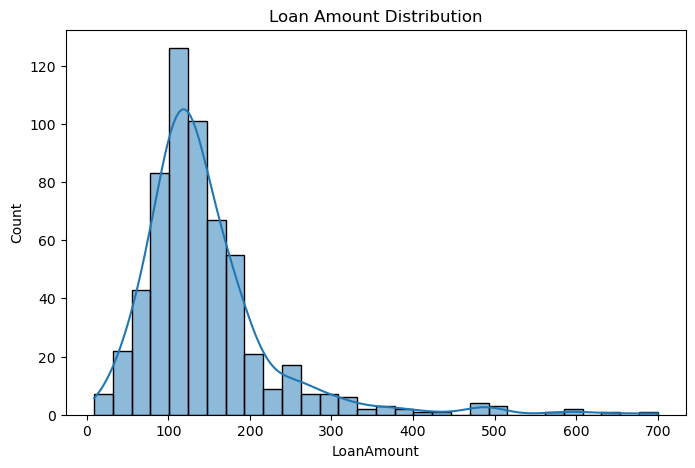

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(

df['LoanAmount'],

bins=30,

kde=True

)

plt.title("Loan Amount Distribution")

plt.show()

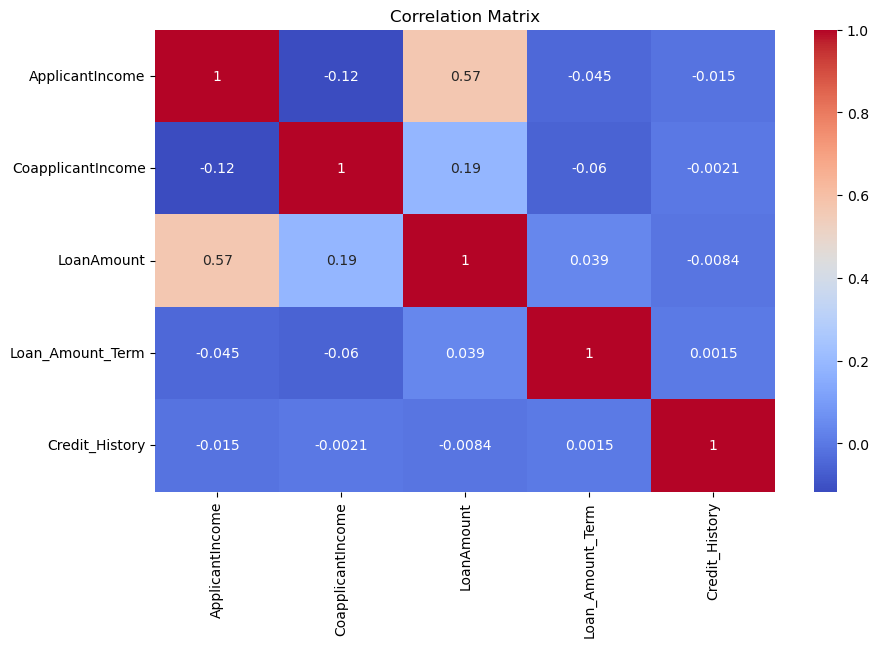

In [11]:
numeric_df=df.select_dtypes(include=['int64','float64'])

corr=numeric_df.corr()

plt.figure(figsize=(10,6))

sns.heatmap(

corr,

annot=True,

cmap='coolwarm'

)

plt.title("Correlation Matrix")

plt.show()

In [12]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [13]:
df.drop(['Loan_ID'],axis=1,inplace=True)

In [14]:
df['Loan_Status'] = df['Loan_Status'].map({

'Y':1,

'N':0

})

In [15]:
categorical_cols = [
    'Gender',
    'Married',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Loan_Status'
]

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [16]:
df.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_1
0,0,5849,0.0,NaN,360.0,1.0,True,False,False,False,False,True,True
1,1,4583,1508.0,128.0,360.0,1.0,True,True,False,False,False,False,False
2,0,3000,0.0,66.0,360.0,1.0,True,True,False,True,False,True,True
3,0,2583,2358.0,120.0,360.0,1.0,True,True,True,False,False,True,True
4,0,6000,0.0,141.0,360.0,1.0,True,False,False,False,False,True,True


In [17]:
print(df['Dependents'].unique())
df['Dependents'] = df['Dependents'].replace('3+',3)
df['Dependents'] = df['Dependents'].fillna(
    df['Dependents'].mode()[0]
)
df['Dependents'] = df['Dependents'].astype(int)
print(df['Dependents'].unique())

print(df['Dependents'].dtype)

print(df['Dependents'].isnull().sum())
df['LoanAmount'] = df['LoanAmount'].fillna(
    df['LoanAmount'].median()
)

df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(
    df['Loan_Amount_Term'].median()
)

df['Credit_History'] = df['Credit_History'].fillna(
    df['Credit_History'].median()
)

['0' '1' '2' '3+' nan]
[0 1 2 3]
int64
0


In [18]:
X=df.drop('Loan_Status_1',axis=1)
y=df['Loan_Status_1']
print(X.isnull().sum())

Dependents                 0
ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                 0
Loan_Amount_Term           0
Credit_History             0
Gender_Male                0
Married_Yes                0
Education_Not Graduate     0
Self_Employed_Yes          0
Property_Area_Semiurban    0
Property_Area_Urban        0
dtype: int64


In [19]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [20]:
from sklearn.linear_model import LogisticRegression
m=LogisticRegression()
m.fit(X_train,y_train)
y_pred=m.predict(X_test)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_pred)

print(accuracy)

0.7886178861788617


In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[18 25]
 [ 1 79]]


In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.95      0.42      0.58        43
        True       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



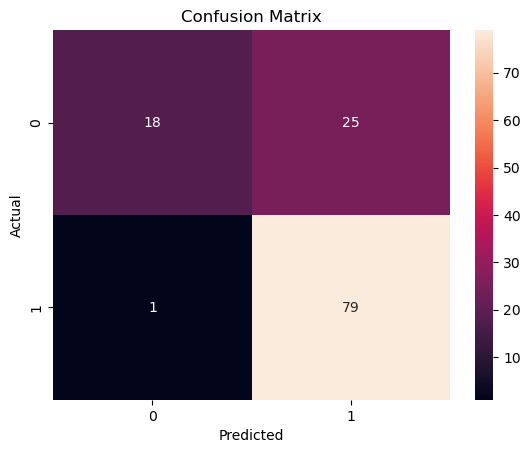

In [24]:
import seaborn as sns

import matplotlib.pyplot as plt

sns.heatmap(

    cm,

    annot=True,

    fmt='d'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [25]:
sample=X_test.iloc[[0]]

print(sample)

     Dependents  ApplicantIncome  CoapplicantIncome  LoanAmount  \
350           0             9083                0.0       228.0   

     Loan_Amount_Term  Credit_History  Gender_Male  Married_Yes  \
350             360.0             1.0         True         True   

     Education_Not Graduate  Self_Employed_Yes  Property_Area_Semiurban  \
350                   False              False                     True   

     Property_Area_Urban  
350                False  


In [26]:
prediction=m.predict(sample)

print(prediction)

[ True]


In [27]:
from sklearn.tree import DecisionTreeClassifier
d=DecisionTreeClassifier(random_state=42)
d.fit(X_train,y_train)
y_p_dt=d.predict(X_test)
accuracy_dt=accuracy_score(y_test,y_p_dt)
print(accuracy_dt)

0.7154471544715447


In [28]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)
y_p_rf=rf.predict(X_test)
accuracy_rf=accuracy_score(y_test,y_p_rf)
print(accuracy_rf)

0.7723577235772358


In [29]:
models=[

'Logistic Regression',

'Decision Tree',

'Random Forest'

]

accuracies=[

accuracy,

accuracy_dt,

accuracy_rf

]
print(accuracies)

[0.7886178861788617, 0.7154471544715447, 0.7723577235772358]


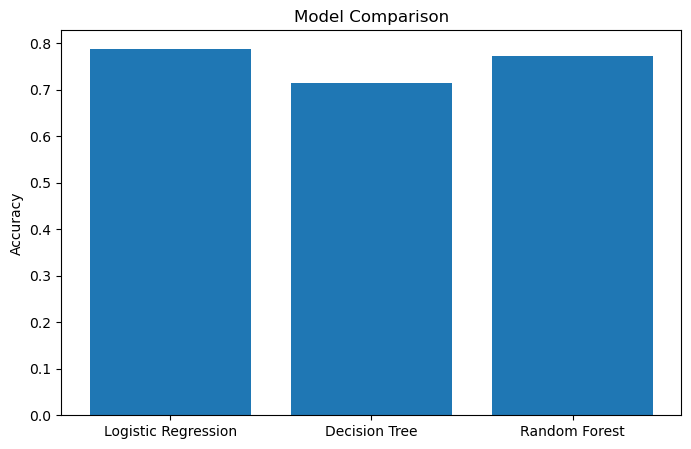

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(

models,

accuracies

)

plt.ylabel("Accuracy")

plt.title(

"Model Comparison"

)

plt.show()

In [31]:
importance=rf.feature_importances_

In [32]:
import pandas as pd

feature_importance=pd.DataFrame({

'Feature':X.columns,

'Importance':importance

})

In [33]:
feature_importance=feature_importance.sort_values(

'Importance',

ascending=False

)

In [34]:
print(feature_importance)

                    Feature  Importance
5            Credit_History    0.261918
1           ApplicantIncome    0.203101
3                LoanAmount    0.177599
2         CoapplicantIncome    0.107260
4          Loan_Amount_Term    0.056440
0                Dependents    0.048649
10  Property_Area_Semiurban    0.030083
7               Married_Yes    0.025914
11      Property_Area_Urban    0.025714
6               Gender_Male    0.023000
8    Education_Not Graduate    0.022232
9         Self_Employed_Yes    0.018090


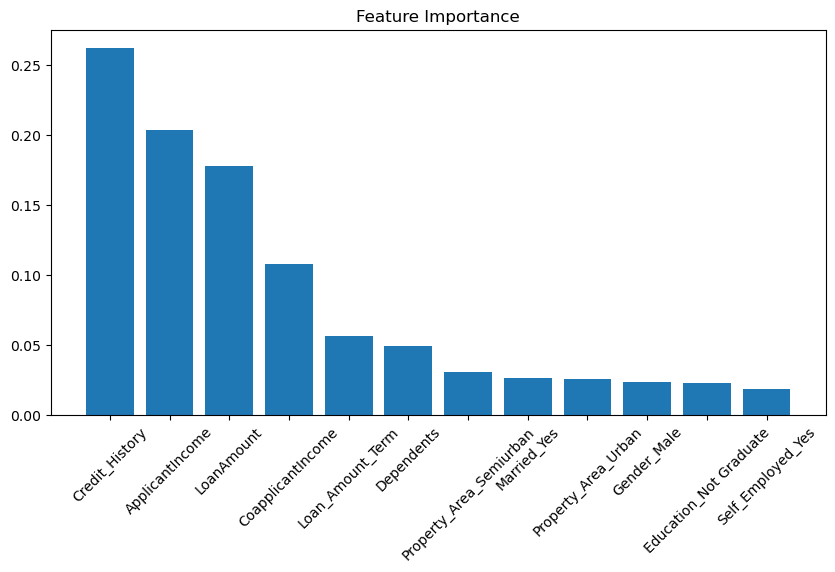

In [35]:
plt.figure(figsize=(10,5))
plt.bar(feature_importance['Feature'],feature_importance['Importance'])
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

In [38]:
import joblib

joblib.dump(m, "loan_model.pkl")

['loan_model.pkl']

In [39]:
print(X.columns.tolist())

['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Gender_Male', 'Married_Yes', 'Education_Not Graduate', 'Self_Employed_Yes', 'Property_Area_Semiurban', 'Property_Area_Urban']
